In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('/content/housing.csv')

In [3]:
print(df.head())

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  


In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB
None


In [5]:
print(df.isnull().sum())

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


In [6]:
df['total_bedrooms'].fillna(
    df['total_bedrooms'].median(),
    inplace=True
)

In [7]:
print(df.isnull().sum())

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64


In [8]:
print(df.describe())

          longitude      latitude  housing_median_age   total_rooms  \
count  20640.000000  20640.000000        20640.000000  20640.000000   
mean    -119.569704     35.631861           28.639486   2635.763081   
std        2.003532      2.135952           12.585558   2181.615252   
min     -124.350000     32.540000            1.000000      2.000000   
25%     -121.800000     33.930000           18.000000   1447.750000   
50%     -118.490000     34.260000           29.000000   2127.000000   
75%     -118.010000     37.710000           37.000000   3148.000000   
max     -114.310000     41.950000           52.000000  39320.000000   

       total_bedrooms    population    households  median_income  \
count    20640.000000  20640.000000  20640.000000   20640.000000   
mean       536.838857   1425.476744    499.539680       3.870671   
std        419.391878   1132.462122    382.329753       1.899822   
min          1.000000      3.000000      1.000000       0.499900   
25%        297.00000

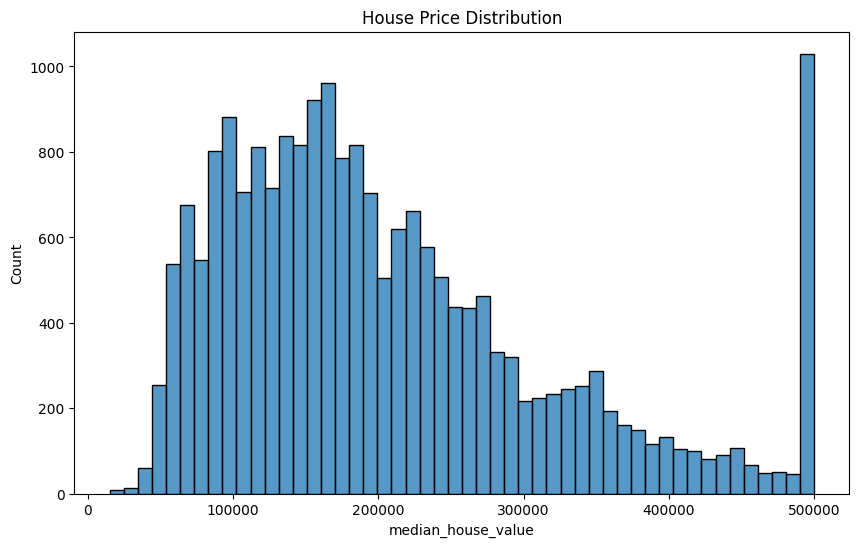

In [9]:
plt.figure(figsize=(10,6))

sns.histplot(df['median_house_value'], bins=50)

plt.title('House Price Distribution')

plt.show()

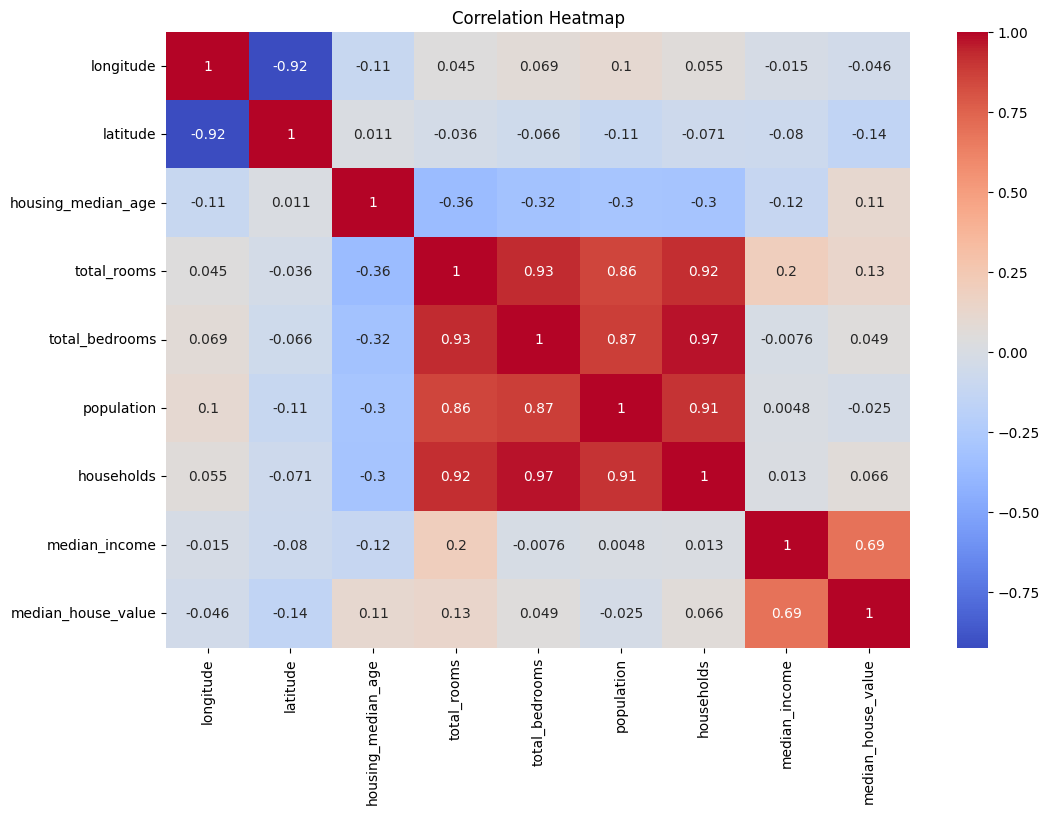

In [10]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

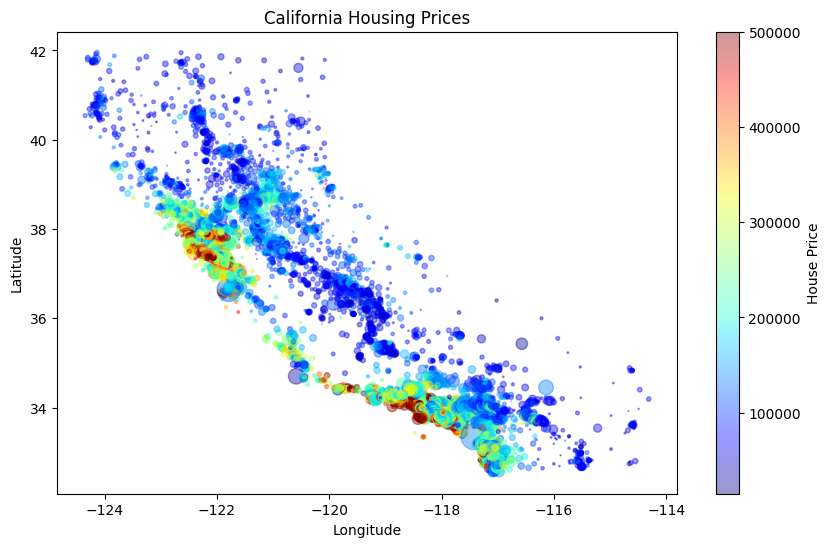

In [11]:
plt.figure(figsize=(10,6))

plt.scatter(
    df['longitude'],
    df['latitude'],
    alpha=0.4,
    s=df['population']/100,
    c=df['median_house_value'],
    cmap='jet'
)

plt.colorbar(label='House Price')

plt.xlabel('Longitude')
plt.ylabel('Latitude')

plt.title('California Housing Prices')

plt.show()

In [12]:
df = pd.get_dummies(
    df,
    columns=['ocean_proximity'],
    drop_first=True
)

In [13]:
X = df.drop('median_house_value', axis=1)

y = df['median_house_value']

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [15]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [16]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [17]:
predictions = model.predict(X_test)

In [18]:
mae = mean_absolute_error(y_test, predictions)

mse = mean_squared_error(y_test, predictions)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, predictions)

print("MAE :", mae)

print("MSE :", mse)

print("RMSE :", rmse)

print("R2 Score :", r2)

MAE : 31631.0186749031
MSE : 2401861420.4517317
RMSE : 49008.7892163409
R2 Score : 0.8167090228826115


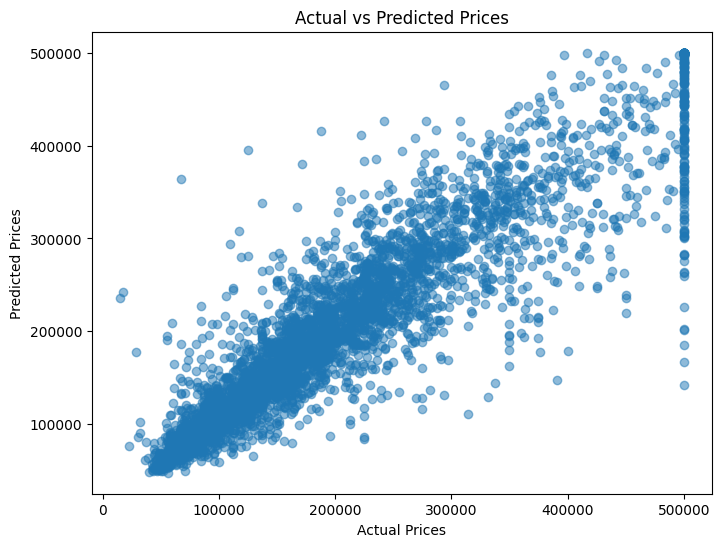

In [19]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, predictions, alpha=0.5)

plt.xlabel("Actual Prices")

plt.ylabel("Predicted Prices")

plt.title("Actual vs Predicted Prices")

plt.show()

In [20]:
importance = model.feature_importances_

feature_names = X.columns

feature_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

feature_df = feature_df.sort_values(
    by='Importance',
    ascending=False
)

print(feature_df)

                       Feature  Importance
7                median_income    0.490717
8       ocean_proximity_INLAND    0.140933
0                    longitude    0.106093
1                     latitude    0.101897
2           housing_median_age    0.052065
5                   population    0.032511
4               total_bedrooms    0.023960
3                  total_rooms    0.023412
6                   households    0.018376
11  ocean_proximity_NEAR OCEAN    0.008793
10    ocean_proximity_NEAR BAY    0.000804
9       ocean_proximity_ISLAND    0.000440


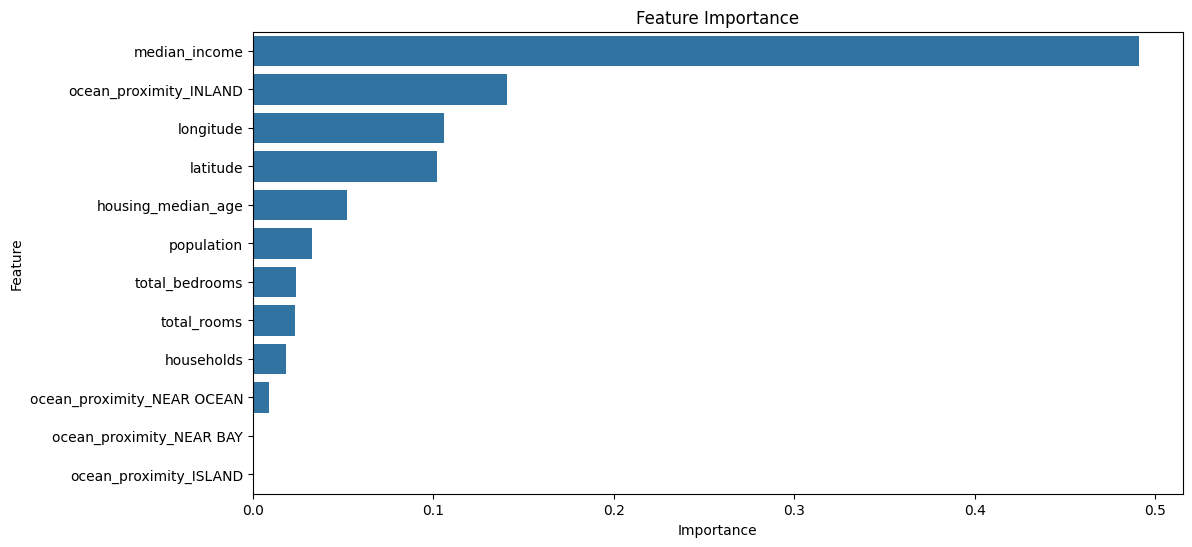

In [21]:
plt.figure(figsize=(12,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_df
)

plt.title("Feature Importance")

plt.show()

In [22]:
train_score = model.score(X_train, y_train)

test_score = model.score(X_test, y_test)

print("Training Score :", train_score)

print("Testing Score :", test_score)

Training Score : 0.9754359111480769
Testing Score : 0.8167090228826115


In [23]:
import joblib

joblib.dump(model, 'housing_model.pkl')

['housing_model.pkl']

In [24]:
from google.colab import files

files.download('housing_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [25]:
custom_data = pd.DataFrame({
    'longitude': [-122.23],
    'latitude': [37.88],
    'housing_median_age': [41],
    'total_rooms': [880],
    'total_bedrooms': [129],
    'population': [322],
    'households': [126],
    'median_income': [8.3252],

    # One Hot Encoded Columns
    'ocean_proximity_INLAND': [0],
    'ocean_proximity_ISLAND': [0],
    'ocean_proximity_NEAR BAY': [1],
    'ocean_proximity_NEAR OCEAN': [0]
})

In [26]:
custom_scaled = scaler.transform(custom_data)

In [27]:
predicted_price = model.predict(custom_scaled)

print("Predicted House Price :", predicted_price[0])

Predicted House Price : 431352.33
